In [3]:
import pandas as pd
import openpyxl

print("Everything is working!")

Everything is working!


In [4]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
c:\Users\Bilal ahmad\OneDrive\Desktop\costomer-retention-predictor\Notebooks

Files and folders here:
['retention-model-predictor.ipynb', 'retention-model-predictorrr.ipynb']


In [5]:
import pandas as pd

file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print(df.shape)
print(df.head())

Dataset loaded successfully!
(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [6]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Quality Check

Before building a machine learning model, we need to understand the quality of the dataset.

In this step, we will check three important aspects of the data:

1. **Missing values** — identify columns containing empty or null values.
2. **Duplicate records** — identify completely repeated rows.
3. **Basic statistics** — understand the numerical and categorical variables using descriptive statistics.

These checks are important because poor-quality data can negatively affect feature engineering and machine learning model performance.

### Why do we perform these checks?

A machine learning model learns patterns from the data we provide. If the dataset contains missing values, duplicate records, or unexpected values, the model may learn incorrect patterns.

Therefore, data inspection should be performed before cleaning, feature engineering, and model training.

In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe(include="all").T)

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Basic statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Understanding the Dataset Columns

Before cleaning the data, we need to understand what each column represents.

Understanding the meaning of each feature is essential because later we will use these transaction-level variables to engineer customer-level features for our retention prediction problem.

The Online Retail dataset contains transaction information. Therefore, one customer may appear in multiple rows because a customer can make multiple purchases.

Our eventual goal is not simply to predict individual transactions. We need to transform transaction-level information into meaningful **customer-level behavioral features** that can help identify retention or churn patterns.

In [8]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
for column in df.columns:
    print("-", column)

Number of rows: 541909
Number of columns: 8

Column names:
- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country


## 4. Data Cleaning

In this section, the dataset will be cleaned by removing duplicate records, handling missing values, and checking for invalid values in important numerical and categorical columns.

The cleaned dataset will then be used for further feature engineering and model development.

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (536641, 8)


## 4.1 Handling Missing Customer IDs

The `CustomerID` column contains missing values.

Since customer-level information is required for customer retention analysis, records without a `CustomerID` will be removed from the dataset.

In [10]:
# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

print("Dataset shape after removing missing CustomerID:", df.shape)
print("Remaining missing CustomerID:", df["CustomerID"].isnull().sum())

Dataset shape after removing missing CustomerID: (401604, 8)
Remaining missing CustomerID: 0


## 4.2 Handling Missing Descriptions

The `Description` column contains missing values.

Since the product description is not required for the customer-level retention analysis, rows with missing `Description` values will be removed from the dataset.

In [11]:
# Remove rows with missing Description
df = df.dropna(subset=["Description"])

print("Dataset shape after removing missing Description:", df.shape)
print("Remaining missing Description:", df["Description"].isnull().sum())

Dataset shape after removing missing Description: (401604, 8)
Remaining missing Description: 0


## 4.3 Checking for Invalid Values

This section checks the `Quantity` and `UnitPrice` columns for zero and negative values.

These columns represent important transaction-level numerical information and should be verified before further processing.

In [12]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

Quantity <= 0: 8872
UnitPrice <= 0: 40


## 4.4 Removing Invalid Transactions

Transactions with a quantity less than or equal to zero and transactions with a unit price less than or equal to zero will be removed.

This ensures that the remaining transaction records contain positive values for both `Quantity` and `UnitPrice`.

In [13]:
# Keep only transactions with positive Quantity and UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

print("Dataset shape after removing invalid transactions:", df.shape)

Dataset shape after removing invalid transactions: (392692, 8)


## 4.5 Final Data Quality Check

After the cleaning process, the dataset is checked again for missing values, duplicate records, and invalid transaction values.

This final check ensures that the dataset is ready for the next stage of the project.

In [14]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nInvalid Quantity:", (df["Quantity"] <= 0).sum())
print("Invalid UnitPrice:", (df["UnitPrice"] <= 0).sum())

print("\nFinal dataset shape:", df.shape)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate rows: 0

Invalid Quantity: 0
Invalid UnitPrice: 0

Final dataset shape: (392692, 8)


## 5. Feature Engineering

Feature engineering involves creating new variables from the existing transaction data.

In this section, a new `TotalAmount` feature will be created by multiplying `Quantity` by `UnitPrice`.

This feature represents the total monetary value of each transaction.

In [15]:
# Calculate the total amount for each transaction
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("TotalAmount feature created successfully.")
display(df[["Quantity", "UnitPrice", "TotalAmount"]].head())

TotalAmount feature created successfully.


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 5.1 Creating Customer-Level RFM Features

The transaction data will be aggregated at the customer level to create three important features:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Total number of purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

These features will form the foundation for the customer retention model.

In [16]:
# Make sure InvoiceDate is in datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Set the reference date as one day after the last transaction
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create customer-level RFM features
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print("RFM dataset shape:", rfm.shape)
display(rfm.head())

RFM dataset shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 5.1 Creating Customer-Level RFM Features

The transaction data will be aggregated at the customer level to create three important features:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Total number of purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

These features will form the foundation for the customer retention model.

In [17]:
# Make sure InvoiceDate is in datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Set the reference date as one day after the last transaction
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create customer-level RFM features
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print("RFM dataset shape:", rfm.shape)
display(rfm.head())

RFM dataset shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 5.2 Creating the Retention Target

A binary `Retention` target variable will be created to classify customers into two groups:

- **1:** Retained customer
- **0:** Non-retained customer

The retention status will be determined using the customer's `Recency` value.


**Note:**
A customer will be considered retained if their most recent purchase occurred within the previous 90 days.

In [18]:
# Define the retention threshold
retention_threshold = 90

# Create the binary retention target
rfm["Retention"] = (rfm["Recency"] <= retention_threshold).astype(int)

# Display the first few rows
display(rfm.head())

# Check the distribution of the target variable
print("\nRetention distribution:")
print(rfm["Retention"].value_counts())

,CustomerID,Recency,Frequency,Monetary,Retention
0,12346.0,326,1,77183.60,0
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,1
3,12349.0,19,1,1757.55,1
4,12350.0,310,1,334.40,0



Retention distribution:
Retention
1    2889
0    1449
Name: count, dtype: int64


## 5.3 Reviewing the Customer-Level Dataset

The customer-level dataset is reviewed after creating the RFM features and the retention target.

The review includes the dataset dimensions, column names, data types, and a sample of the resulting customer-level records.

In [19]:
print("RFM dataset shape:", rfm.shape)

print("\nColumns:")
print(rfm.columns.tolist())

print("\nData types:")
print(rfm.dtypes)

print("\nFirst 5 records:")
display(rfm.head())

RFM dataset shape: (4338, 5)

Columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Retention']

Data types:
CustomerID    float64
Recency         int64
Frequency       int64
Monetary      float64
Retention       int64
dtype: object

First 5 records:


,CustomerID,Recency,Frequency,Monetary,Retention
0,12346.0,326,1,77183.60,0
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,1
3,12349.0,19,1,1757.55,1
4,12350.0,310,1,334.40,0


## 5.4 Creating Interaction Features

Interaction features combine two or more existing variables to capture relationships between customer-level characteristics.

In this section, three new features will be created from the RFM variables:

- **RecencyFrequency:** interaction between Recency and Frequency
- **FrequencyMonetary:** interaction between Frequency and Monetary
- **RecencyMonetary:** interaction between Recency and Monetary

These engineered features will be added to the customer-level dataset for use in the machine-learning model.

In [20]:
# Create interaction features
rfm["RecencyFrequency"] = rfm["Recency"] * rfm["Frequency"]

rfm["FrequencyMonetary"] = rfm["Frequency"] * rfm["Monetary"]

rfm["RecencyMonetary"] = rfm["Recency"] * rfm["Monetary"]

# Display the updated dataset
print("Updated RFM dataset shape:", rfm.shape)

print("\nUpdated columns:")
print(rfm.columns.tolist())

display(rfm.head())

Updated RFM dataset shape: (4338, 8)

Updated columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Retention', 'RecencyFrequency', 'FrequencyMonetary', 'RecencyMonetary']


,CustomerID,Recency,Frequency,Monetary,Retention,RecencyFrequency,FrequencyMonetary,RecencyMonetary
0,12346.0,326,1,77183.60,0,326,77183.60,25161853.60
1,12347.0,2,7,4310.00,1,14,30170.00,8620.00
2,12348.0,75,4,1797.24,1,300,7188.96,134793.00
3,12349.0,19,1,1757.55,1,19,1757.55,33393.45
4,12350.0,310,1,334.40,0,310,334.40,103664.00


## 5.5 Preparing Features and Target Variables

The customer-level dataset will now be divided into two parts:

- **Features (`X`)**: Variables used by the machine-learning model to make predictions.
- **Target (`y`)**: The variable that the model will learn to predict.

The `CustomerID` column will not be used as a predictive feature because it is an identifier rather than a customer behavior characteristic.

The `Retention` column will be used as the target variable.

In [21]:
# Define the feature columns
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "RecencyFrequency",
    "FrequencyMonetary",
    "RecencyMonetary"
]

# Create feature matrix
X = rfm[feature_columns]

# Create target variable
y = rfm["Retention"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (4338, 6)
Target shape: (4338,)

Feature columns:
['Recency', 'Frequency', 'Monetary', 'RecencyFrequency', 'FrequencyMonetary', 'RecencyMonetary']

Target distribution:
Retention
1    2889
0    1449
Name: count, dtype: int64


## 5.6 Splitting the Dataset into Training and Testing Sets

The dataset will be divided into two subsets:

- **Training set:** 80% of the customer records, used to train the machine-learning model.
- **Testing set:** 20% of the customer records, used to evaluate the model on unseen data.

A fixed random state will be used to make the split reproducible.

Stratification will be applied to maintain a similar distribution of retained and non-retained customers in both subsets.

In [22]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features shape: (3470, 6)
Testing features shape: (868, 6)

Training target shape: (3470,)
Testing target shape: (868,)

Training target distribution:
Retention
1    2311
0    1159
Name: count, dtype: int64

Testing target distribution:
Retention
1    578
0    290
Name: count, dtype: int64


## 5.7 Feature Scaling

The numerical features have different ranges and scales.

Feature scaling will be applied so that the features are placed on a comparable scale before model training.

`StandardScaler` will be used to standardize the features based on the training data.

The scaler will be fitted only on the training set and then applied to both the training and testing sets.

In [23]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled training features shape:", X_train_scaled.shape)
print("Scaled testing features shape:", X_test_scaled.shape)

Scaled training features shape: (3470, 6)
Scaled testing features shape: (868, 6)


## 5.8 Training the Random Forest Classifier

A Random Forest Classifier will be used as the first machine-learning model for customer retention prediction.

The model will be trained using the scaled training features and the corresponding retention labels.

Random Forest combines multiple decision trees to produce a classification result and will serve as the baseline model for this project.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 5.9 Making Predictions on the Test Set

The trained Random Forest Classifier will be used to make predictions on the testing dataset.

The predictions will represent the estimated retention status of customers in the test set.

The predicted values will then be compared with the actual retention values to evaluate the performance of the model.

In [25]:
# Make predictions on the test data
y_pred = rf_model.predict(X_test_scaled)

print("Predictions generated successfully.")

print("\nFirst 10 predicted values:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

Predictions generated successfully.

First 10 predicted values:
[0 1 1 1 1 0 1 1 1 1]

First 10 actual values:
[0 1 1 1 1 0 1 1 1 1]


## 5.10 Evaluating the Classification Model

The performance of the Random Forest Classifier will be evaluated using several classification metrics.

The evaluation will include:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

These metrics will be calculated by comparing the predicted retention values with the actual retention values from the testing dataset.

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation Results
------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0

Confusion Matrix:
[[290   0]
 [  0 578]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       290
           1       1.00      1.00      1.00       578

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



## 5.11 Confusion Matrix Visualization

The confusion matrix will be visualized to provide a graphical representation of the model's classification results.

The matrix shows the number of correctly and incorrectly classified customers for each retention class.

The visualization will make it easier to examine the model's prediction results.

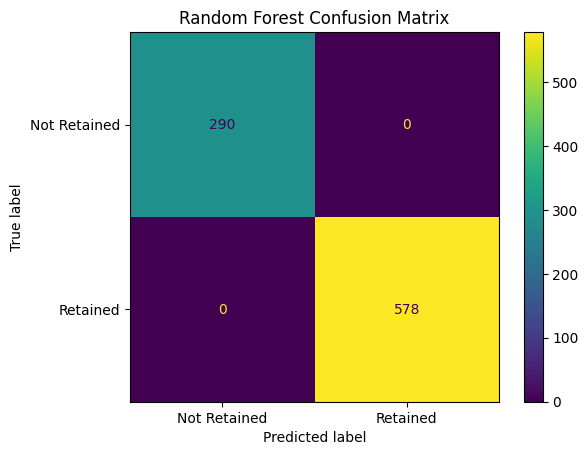

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create the confusion matrix display
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Retained", "Retained"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## 5.12 Feature Importance Analysis

The Random Forest model provides an importance score for each input feature.

These scores will be used to identify the relative contribution of the RFM and interaction features to the model's predictions.

The feature importance values will be organized into a table and displayed in descending order.

In [28]:
# Create a feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
0,Recency,0.642791
3,RecencyFrequency,0.164517
5,RecencyMonetary,0.059396
1,Frequency,0.052396
4,FrequencyMonetary,0.042951
2,Monetary,0.037950


## 5.13 Visualizing Feature Importance

The feature importance scores will be presented using a bar chart.

The visualization will show the relative importance of each feature used by the Random Forest model.

Features will be displayed in descending order of their importance scores.

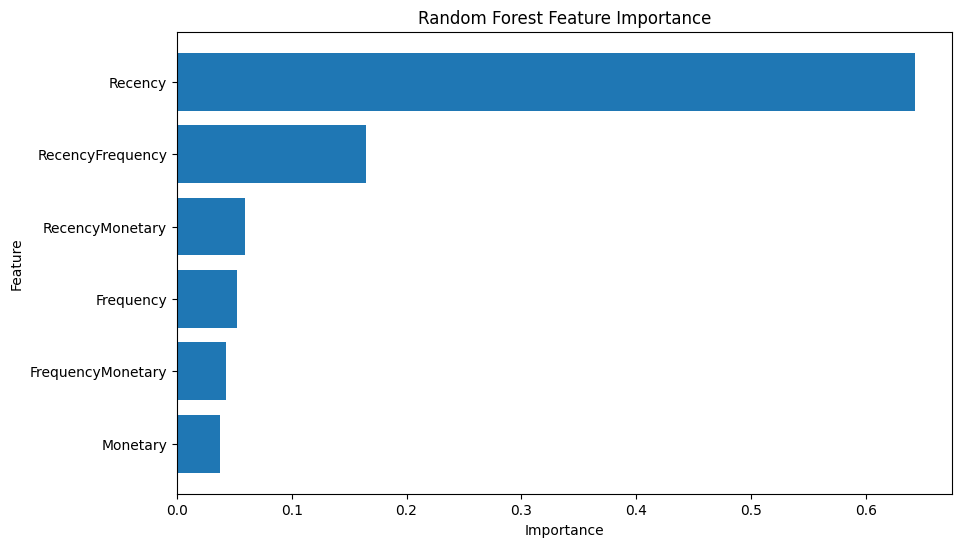

In [29]:
# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

## 5.14 Training the Logistic Regression Model

A Logistic Regression model will be trained as a second classification model for customer retention prediction.

The model will use the same training and testing datasets as the Random Forest model.

Using the same data allows the performance of both models to be compared fairly.

In [30]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 5.15 Making Logistic Regression Predictions

The trained Logistic Regression model will be used to predict the retention status of customers in the testing dataset.

The predicted retention values will be compared with the actual values from the testing dataset.

In [31]:
# Make predictions using Logistic Regression
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions generated successfully.")

print("\nFirst 10 predicted values:")
print(y_pred_logistic[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

Logistic Regression predictions generated successfully.

First 10 predicted values:
[0 1 1 1 1 0 1 1 1 1]

First 10 actual values:
[0 1 1 1 1 0 1 1 1 1]


## 5.16 Evaluating the Logistic Regression Model

The Logistic Regression model will be evaluated using the same classification metrics used for the Random Forest model.

The evaluation will include:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Using the same evaluation metrics allows the performance of both classification models to be compared consistently.

In [33]:

# Calculate Logistic Regression evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Evaluation Results")
print("--------------------------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1-Score :", f1_logistic)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Evaluation Results
--------------------------------------
Accuracy : 0.9953917050691244
Precision: 0.993127147766323
Recall   : 1.0
F1-Score : 0.996551724137931

Confusion Matrix:
[[286   4]
 [  0 578]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       290
           1       0.99      1.00      1.00       578

    accuracy                           1.00       868
   macro avg       1.00      0.99      0.99       868
weighted avg       1.00      1.00      1.00       868

